<a href="https://colab.research.google.com/github/Dylan-Sensei/Analisis-everpeak/blob/main/Sprint09_Webinar29_Practico_Alumnos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 9 · Webinar 29 · Data Analytics práctico  
**Student Version · Proyecto Sprint 9: Experimento A/B en página de inicio (Landing Experiment)**


## Objetivo de la sesión práctica

Al finalizar esta clase, podrás:

1. Cargar y validar un dataset de un **experimento A/B**.
2. Realizar un **EDA básico** para detectar problemas de calidad (tipos, duplicados, valores fuera de rango).
3. Comparar **métricas clave** entre las versiones **A** y **B**:
   - **Gasto promedio** (solo usuarios que convirtieron)
   - **Tasa de conversión** (usuarios que convierten / total)
4. Aplicar pruebas simples para tomar una decisión:
   - **t-test** para comparar promedios
   - **Chi-cuadrado** para comparar proporciones (conversiones)
5. Escribir conclusiones claras: **qué pasó, qué significa, y qué haría negocio**.


## Contexto del negocio

Un equipo de producto probó dos versiones de la **página de inicio (landing page)**:

- **Versión A:** diseño actual  
- **Versión B:** nuevo diseño (hipótesis: mejora conversión y/o gasto)

El objetivo del experimento es responder preguntas como:

- ¿La versión B **convierte más** usuarios?
- Entre quienes convierten, ¿la versión B genera **más gasto**?

⚠️ Importante:
- **Conversión** suele ser una variable binaria (`0/1`).
- **Gasto** es numérica y suele tener mucha variabilidad.


## Dataset del proyecto

En el proyecto trabajaremos con un archivo tipo CSV llamado `landing_experiment_sintetico_40k.csv`.

Columnas típicas (pueden variar ligeramente según tu versión):
- `user_id` — identificador único del usuario  
- `date` — fecha en que el usuario participó en el experimento  
- `landing` — variante del experimento (`A` o `B`)  
- `converted` — si convirtió (1) o no (0)  
- `gasto` — gasto del usuario (normalmente 0 si no convirtió, o gasto positivo si convirtió)  
- Otras variables de segmentación: `region`, `dispositivo`, `traffic_source`, `user_type`, etc.

📌 **Checklist de entregables (lo que se espera en el proyecto):**
- Validación básica de datos (tipos, duplicados, rango de fechas)
- Comparación de métricas A vs B
- Pruebas estadísticas simples + interpretación
- Conclusión de negocio y recomendación


In [ ]:
# ============================================================
# Imports y configuración (ejecuta esta celda primero)
# ============================================================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---

# Ejercicio 1 · Cargar y explorar el dataset (15 min)

**Meta:** cargar datos, ver estructura y entender qué representa cada columna.

### 1.1 Cargar datos

Usaremos el archivo `landing_experiment_sintetico_40k.csv`. Disponible en GitHub:


In [ ]:
# Tu turno: carga el dataset desde GitHub

url = "https://raw.githubusercontent.com/ljpiere/tpdata_python/refs/heads/main/DA/datasets/landing_experiment_sintetico_40k.csv"

# carga el dataset en una variable llamada df
df = pd.read_csv(url)

# TODO: muestra las primeras filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,825db3f6-4232-44dc-bf70-37c413362d91,2026-02-22,A,Sur,Mobile,Ads,Nuevo,0,0.00
1,42c32e9f-b626-4416-88e8-092b1fbb96d2,2026-02-13,A,Norte,Desktop,Ads,Nuevo,1,57.66
2,85eee9b6-ed60-4124-bee0-e9f02d530335,2026-02-25,A,Sur,Desktop,Organic,Recurrente,0,0.00
3,873fcb56-7fed-4b8c-a0b3-ff94bcd10acc,2026-02-20,A,Sur,Mobile,Organic,Nuevo,0,0.00
4,e7cf8f07-f65b-4686-b733-daf99dab571e,2026-02-03,B,Centro,Mobile,Organic,Recurrente,1,63.26


In [ ]:
# Vista general: dimensiones y tipos

# TODO: imprime las dimensiones del dataset
print("Dimensiones (filas, columnas):", df.shape)
print('')
# TODO: revisa la estructura general
df.info()

Dimensiones (filas, columnas): (40000, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          39851 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  39762 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Mini-análisis (texto en Markdown):**
- ¿Cuántas filas y columnas hay?
- ¿Qué columnas parecen ser numéricas? ¿cuáles categóricas?
- ¿Qué columna representa la variante (A/B)? ¿y la conversión?

> Escribe tus observaciones debajo de este bloque.


### 1.2 Diccionario de datos (para la sesión)

Completa este diccionario con lo que observes:

- `user_id`: __________  
- `date`: __________  
- `landing`: __________  
- `converted`: __________  
- `gasto`: __________  
- otras columnas: __________


---

# Ejercicio 2 · Revisión de calidad de datos (15 min)

**Meta:** asegurar que el experimento está bien formado.

Checklist:
1. ¿Hay valores faltantes?
2. ¿Hay `user_id` duplicados?
3. ¿`landing` solo tiene A y B?
4. ¿`converted` solo tiene 0 y 1?
5. ¿`gasto` tiene valores negativos? (no debería)


In [ ]:
# TODO: revisa valores faltantes por columna
# Escribe una línea que calcule los nulos por columna

df.isna().sum()

,0
user_id,0
date,0
landing,0
region,149
dispositivo,0
traffic_source,238
user_type,0
converted,0
gasto,0


In [ ]:
# 2.1 Porcentaje de faltantes por columna

# TODO: calcula el porcentaje de valores faltantes y ordénalo de mayor a menor
missing_pct = 100*df.isna().sum()/len(df)

# TODO: muéstralo como DataFrame y redondea a 2 decimales
round(missing_pct.sort_values(ascending= False),2)

,0
traffic_source,0.60
region,0.37
user_id,0.00
landing,0.00
date,0.00
dispositivo,0.00
user_type,0.00
converted,0.00
gasto,0.00


In [ ]:
# 2.2 Duplicados en user_id
# Si cada usuario aparece una sola vez, no debería haber duplicados.

# TODO: calcula cuántos user_id duplicados existen
duplicados_user = df.duplicated(subset=['user_id']).sum()

# TODO: imprime el resultado
print("Duplicados en user_id:", duplicados_user)

Duplicados en user_id: 0


In [ ]:
# 2.3 Valores únicos en variables clave

# TODO: revisa los valores distintos de landing
print("Valores en landing:", df.landing.unique()) #df['landing'].unique()

# TODO: revisa los valores distintos de converted
print("Valores en converted:", df['converted'].unique())

Valores en landing: ['A' 'B']
Valores en converted: [0 1]


In [ ]:
# Espacio opcional de validación adicional
# Usa esta celda si quieres probar una segunda forma de revisar valores únicos.

# Ejemplo:
sorted(df["landing"].dropna().unique())

['A', 'B']

In [ ]:
# Revisión rápida de gasto

# TODO: imprime el valor mínimo de gasto
print("Gasto mínimo:", df.gasto.min())

# TODO: imprime el valor máximo de gasto
print("Gasto máximo:", df.gasto.max())

# TODO: muestra estadísticas descriptivas
df.describe()

Gasto mínimo: -97.49
Gasto máximo: 383.21


,converted,gasto
count,40000.000000,40000.000000
mean,0.131375,8.902854
std,0.337814,26.006051
min,0.000000,-97.490000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,383.210000


### 2.4 Fecha: rango temporal del experimento (opcional pero recomendado)

Un experimento A/B normalmente tiene un rango de fechas definido.
Revisemos mínimos y máximos.


In [ ]:
# Convierte date a datetime y revisa el rango temporal del experimento

# TODO: convierte la columna date usando errors="coerce"
df["date"] = pd.to_datetime(df['date'], errors = 'coerce')

# TODO: imprime fecha mínima y fecha máxima
print("Fecha mínima:", df.date.min())
print("Fecha máxima:", df.date.max())

Fecha mínima: 2026-02-01 00:00:00
Fecha máxima: 2026-02-28 00:00:00


In [ ]:
# ¿Hay fechas inválidas?

# TODO: cuenta cuántas fechas quedaron como NaT
print("Fechas inválidas (NaT):", df.date.isna().sum())

Fechas inválidas (NaT): 0


### Analizando valores negativos en gasto

In [ ]:
df[df.gasto < 0].shape

(11, 9)

In [ ]:
100 * (df[df.gasto < 0].shape[0] / df.shape[0])

0.0275

In [ ]:
data = df.copy()

In [ ]:
data = data[data.gasto >= 0]
data.shape

(39989, 9)

✍️ **Decisiones (documentación):**
Si encontraste problemas, documenta qué harías. Ejemplos:

- Si hay duplicados en `user_id`: ¿los eliminas? ¿por qué?
- Si hay gasto negativo: ¿filtras? ¿lo marcas como error?
- Si `date` tiene NaT: ¿remueves esas filas?

> Nota: En esta clase **no** buscamos “perfección”, buscamos hábitos sanos: revisar y documentar.


### 2.5 Limpieza mínima (para poder analizar)

Aplicaremos una limpieza **muy simple** y conservadora:

- Remover filas con `landing` faltante
- Asegurar `converted` como entero 0/1 (si es posible)
- Reemplazar `gasto` faltante por 0 (si existe), porque suele significar “no gastó”

⚠️ Si tu dataset real es distinto, ajusta con criterio y documenta.


In [ ]:
# Copia de trabajo para no modificar df directamente
# TODO: crea una copia llamada data
# data = ...

# 1) Eliminar filas sin landing
# TODO: aplica una limpieza mínima
data = data.dropna(subset = ['landing'])
print('Valores en Landing:', data['landing'].unique())
data.shape

Valores en Landing: ['A' 'B']


(39989, 9)

In [ ]:
# 2) Asegurar converted como variable numérica 0/1 cuando sea posible
# 0/1 <-> False / True
# TODO: convierte converted a numérico usando errors="coerce"
data["converted"] = pd.to_numeric(data['converted'], errors = 'coerce')
print('Valores en Converted:', data['converted'].unique())

Valores en Converted: [0 1]


In [ ]:
# 3) Gasto: convertir a numérico y completar faltantes con 0

# TODO: convierte gasto a numérico
data["gasto"] = pd.to_numeric(data['gasto'], errors = 'coerce')

# TODO: rellena faltantes de gasto con 0
data["gasto"] = data['gasto'].fillna(0)

# TODO: imprime las dimensiones después de la limpieza mínima
print("Dimensiones después de limpieza mínima:", data.shape)

# TODO: visualiza algunas columnas clave
data[['user_id','landing', 'converted', 'gasto']].head()

Dimensiones después de limpieza mínima: (39989, 9)


,user_id,landing,converted,gasto
0,825db3f6-4232-44dc-bf70-37c413362d91,A,0,0.00
1,42c32e9f-b626-4416-88e8-092b1fbb96d2,A,1,57.66
2,85eee9b6-ed60-4124-bee0-e9f02d530335,A,0,0.00
3,873fcb56-7fed-4b8c-a0b3-ff94bcd10acc,A,0,0.00
4,e7cf8f07-f65b-4686-b733-daf99dab571e,B,1,63.26


---

# Ejercicio 3 · Gasto promedio (A vs B) (15 min)

**Pregunta:** Entre quienes convirtieron (`converted = 1`), ¿el gasto promedio es diferente en A vs B?

### Paso 1: filtrar solo convertidos
### Paso 2: calcular promedio y tamaño de muestra (n)
### Paso 3: visualizar (histograma simple o boxplot)


In [ ]:
# 3.1 Filtrar solo usuarios que convirtieron

# TODO: crea un DataFrame conv solo con converted == 1
conv = data[data['converted'] == 1]

# TODO: imprime cuántos usuarios convirtieron
print("Usuarios que convirtieron:", len(conv)) #conv['user_id'].nunique()

# TODO: revisa cuántos hay por variante
print(conv.groupby('landing')['user_id'].nunique().reset_index())
print()
conv.head()

Usuarios que convirtieron: 5244
  landing  user_id
0       A     2351
1       B     2893



,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
1,42c32e9f-b626-4416-88e8-092b1fbb96d2,2026-02-13,A,Norte,Desktop,Ads,Nuevo,1,57.66
4,e7cf8f07-f65b-4686-b733-daf99dab571e,2026-02-03,B,Centro,Mobile,Organic,Recurrente,1,63.26
22,e910903c-a798-4fc2-84a3-be03d0d3346f,2026-02-28,A,Sur,Mobile,Organic,Nuevo,1,93.88
23,a50dfc89-e49c-4a97-97f5-805943ee5702,2026-02-26,A,Sur,Mobile,Referral,Nuevo,1,44.05
31,983038e8-df74-4662-a06d-b43c5e87f018,2026-02-28,A,Sur,Desktop,Email,Nuevo,1,17.98


In [ ]:
# 3.2 Resumen por variante: tamaño (n) y gasto promedio

# TODO: agrupa por landing y calcula:
# - count
# - mean
# - median
# - std
resumen_gasto = conv.groupby('landing').agg(
    total_usarios = ('user_id', 'count'),
    gasto_promedio = ('gasto', 'mean'),
    gasto_mediano = ('gasto', 'median'),
    desv_gasto = ('gasto', 'std')
    )

resumen_gasto

,total_usarios,gasto_promedio,gasto_mediano,desv_gasto
landing,,,,
A,2351,67.813420,61.06,32.732713
B,2893,68.212503,60.98,34.224068


<Figure size 640x480 with 0 Axes>

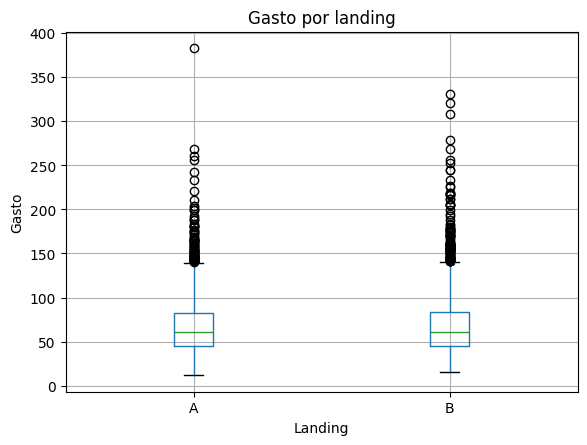

In [ ]:
# 3.3 Visualización simple del gasto por variante
# Puedes usar boxplot o histograma.

# TODO: crea una visualización para comparar gasto entre A y B
# Pista: usa conv.boxplot(...)

plt.figure()
conv.boxplot(column = 'gasto', by = 'landing')
plt.title('Gasto por landing')
plt.suptitle('')
plt.ylabel('Gasto')
plt.xlabel('Landing')
plt.show()

✍️ **Interpretación visual:**
- ¿Ves una diferencia clara entre A y B?
- ¿Hay muchos valores extremos (outliers)?
- ¿La distribución parece “rara” (muy sesgada)?

> Escribe 2–3 frases.


---

# Ejercicio 4 · Prueba t para comparar gasto promedio (15 min)

Ahora pasamos de “ver diferencias” a **validar con una prueba estadística simple**.

### ¿Qué estamos comparando?
- Dos grupos independientes (usuarios que vieron A vs usuarios que vieron B)
- Variable numérica: `gasto`
- Solo usuarios que convirtieron (porque quienes no convierten suelen tener gasto 0)

### Prueba elegida: t-test (Welch)
Usamos `ttest_ind(..., equal_var=False)` porque **no asumimos varianzas iguales** (es más seguro).

📌 Interpretación (regla simple):
- Si `p_value < 0.05`: evidencia de diferencia (al nivel 5%)
- Si `p_value >= 0.05`: no hay evidencia suficiente para afirmar diferencia

⚠️ Esto no significa “B es mejor” automáticamente: hay que mirar también el **tamaño** de la diferencia (promedios).


- **Hipotesis nula (HO)**: El gasto promedio de los usuarios del landing  A es (estadisticamente) igual al gasto promedio del grupo B
- **Hipotesis alternativa (HA)**: El gasto promedio del grupo A es (estadisticamente) distinto al gasto promedio del grupo B

In [ ]:
# 4.1 Separar gasto por variante (solo convertidos)

# TODO: crea dos Series:
gasto_A = conv[conv['landing'] == 'A']['gasto']
gasto_B = conv[conv['landing'] == 'B']['gasto']

# TODO: imprime n y promedio de cada grupo
print('Cantidad de usuarios en el grupo A:', len(gasto_A))
print('Gasto promedio del grupo A:', gasto_A.mean())
print('')
print('Cantidad de usuarios en el grupo B:', len(gasto_B))
print('Gasto promedio del grupo B:', gasto_B.mean())

Cantidad de usuarios en el grupo A: 2351
Gasto promedio del grupo A: 67.81341982135262

Cantidad de usuarios en el grupo B: 2893
Gasto promedio del grupo B: 68.21250259246456


In [ ]:
# 4.2 t-test de Welch (varianzas no asumidas iguales)

# TODO: aplica stats.ttest_ind(..., equal_var=False)
t_stat, p_value = stats.ttest_ind(gasto_A, gasto_B, equal_var = False)

# TODO: imprime estadístico t y p-value
print("t_stat:", t_stat)
print("p_value:", p_value)

t_stat: -0.43019117791269745
p_value: 0.6670747352117203


### 4.3 Conclusión en lenguaje de negocio

Completa:

- Promedio A: ______  
- Promedio B: ______  
- p-value: ______

**Conclusión (1–2 frases):**  
“Con un nivel de significancia del 5%, _________ evidencia de que el gasto promedio entre convertidos sea diferente entre A y B.  
En términos prácticos, B tiene un gasto promedio estadisticamente similar que A (mayor/menor/similar).”


---

# Ejercicio 5 · Tasa de conversión (A vs B) + Chi-cuadrado (15 min)

**Pregunta:** ¿La versión B convierte una proporción distinta de usuarios que la A?

### 5.1 Tasa de conversión
Definición:
$$
	\text{conversion_rate} = \frac{\#converted=1}{\#total}
$$

### 5.2 Prueba estadística: Chi-cuadrado (2×2)

Construimos una tabla de contingencia:

| landing | converted=0 | converted=1 |
|---|---:|---:|
| A | ... | ... |
| B | ... | ... |

Luego aplicamos `chi2_contingency`.  
Regla simple:
- `p_value < 0.05` → evidencia de que la conversión depende de la variante (A/B)


In [ ]:
# 5.1 Primera revisión rápida
# TODO: calcula la tasa de conversión promedio por landing
# Pista: converted suele estar codificada como 0/1

round(100*data.groupby('landing')['converted'].mean(),2)

,converted
landing,
A,12.07
B,14.11


In [ ]:
# TODO: revisa cuántas observaciones hay por variante
# Esto te ayuda a validar tamaños de muestra

data.groupby('landing')['converted'].count()

,converted
landing,
A,19481
B,20508


In [ ]:
# 5.1 Tasa de conversión por variante

# TODO: calcula conversion rate por landing
conv_rate = data.groupby('landing')['converted'].mean()

# TODO: calcula cantidad total por variante
counts = data.groupby('landing')['converted'].count()

In [ ]:
# TODO: construye un DataFrame resumen con:
# - n_total
# - conversion_rate

resumen_conv = pd.concat([counts, conv_rate], axis = 1)
resumen_conv.columns = ['n_total', 'conversion_rate']
resumen_conv

,n_total,conversion_rate
landing,,
A,19481,0.120682
B,20508,0.141067


In [ ]:
# 5.2 Tabla de contingencia 2x2 (landing vs converted)

# TODO: crea una tabla de contingencia
tabla = pd.crosstab(data['landing'], data['converted'])
tabla

converted,0,1
landing,,
A,17130,2351
B,17615,2893


In [ ]:
# 5.3 Prueba Chi-cuadrado

# TODO: aplica chi2_contingency(tabla)
chi2, p_value, dof, expected = chi2_contingency(tabla)

# TODO: imprime chi2, p_value y dof
print("Chi2:", chi2)
print("p-value:", p_value)
print("Grados de libertad:", dof)

# TODO opcional: convierte expected en DataFrame para revisarlo
expected_df = pd.DataFrame(
    expected,
    index=tabla.index,
    columns=tabla.columns
)

print(expected_df)
1.5762767768347977e-09

Chi2: 36.25897000721473
p-value: 1.7276300574732627e-09
Grados de libertad: 1
converted             0            1
landing                             
A          16926.338368  2554.661632
B          17818.661632  2689.338368


- **H0**: La tasa de conversion de los usuarios del landing B es igual a la de los usuarios del grupo A
- **HA**: La tasa de conversion de los usuarios del landing B es distinta a la de los usuarios del grupo A

### 5.4 Conclusión de conversión (lenguaje de negocio)

Completa:

- Conversion rate A: ______  
- Conversion rate B: ______  
- p-value: ______

**Conclusión (1–2 frases):**  
“Con un nivel de significancia del 5%, _________ evidencia de que la tasa de conversión sea diferente entre A y B.  
En términos prácticos, B convierte _________ que A (más/menos/similar).”


In [ ]:
conversion = data.groupby('landing')['converted'].sum()
conversion

,converted
landing,
A,2351
B,2893


In [ ]:
counts

,converted
landing,
A,19481
B,20508


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(
    count = conversion.values,
    nobs = counts.values
)

In [ ]:
print("pvalor de Z-test:", p_value)

pvalor de Z-test: 1.5762767768347977e-09


---

# Ejercicio 6 · Segmentación rápida (5 min)

A veces, el efecto cambia por segmento (región, dispositivo, fuente de tráfico).

**Meta:** calcular la tasa de conversión por `landing` dentro de **un** segmento.

Elige una columna de segmentación que exista en tu dataset, por ejemplo:
- `region`
- `dispositivo`
- `traffic_source`
- `user_type`

Si tu dataset no tiene esas columnas, puedes saltar este ejercicio.


In [ ]:
data.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,825db3f6-4232-44dc-bf70-37c413362d91,2026-02-22,A,Sur,Mobile,Ads,Nuevo,0,0.00
1,42c32e9f-b626-4416-88e8-092b1fbb96d2,2026-02-13,A,Norte,Desktop,Ads,Nuevo,1,57.66
2,85eee9b6-ed60-4124-bee0-e9f02d530335,2026-02-25,A,Sur,Desktop,Organic,Recurrente,0,0.00
3,873fcb56-7fed-4b8c-a0b3-ff94bcd10acc,2026-02-20,A,Sur,Mobile,Organic,Nuevo,0,0.00
4,e7cf8f07-f65b-4686-b733-daf99dab571e,2026-02-03,B,Centro,Mobile,Organic,Recurrente,1,63.26


In [ ]:
data['region'] = data['region'].fillna('desconocido')
regiones = data.region.unique()

for region in regiones:
  dataset = data[data['region'] == region]
  conversion = dataset.groupby('landing')['converted'].sum()
  counts = dataset.groupby('landing')['converted'].count()

  z_stat, p_value = proportions_ztest(
    count = conversion.values,
    nobs = counts.values
  )
  if p_value < 0.05:
    print(f'Para la region {region} rechazamos H0')
    print('')
  else:
    print(f'Para la region {region} aceptamos H0')
    print('')



Para la region Sur rechazamos H0

Para la region Norte rechazamos H0

Para la region Centro rechazamos H0

Para la region Oriente aceptamos H0

Para la region Occidente aceptamos H0

Para la region desconocido aceptamos H0



✍️ **Mini-insight (1 frase):**
- ¿En qué segmento parece que B mejora más (si es que mejora)?


---

# Reporte final (5 min)

Completa este mini-reporte. La idea es practicar cómo comunicar resultados.

## 1) ¿Qué medimos?
- Métrica 1 (conversión): _________  
- Métrica 2 (gasto en convertidos): _________  

## 2) Resultados principales
- Conversión A vs B: _________  
- Gasto promedio (convertidos) A vs B: _________  

## 3) Evidencia estadística (regla simple con p-value)
- p-value conversión (Chi-cuadrado): _________  
- p-value gasto (t-test): _________  

## 4) Conclusión de negocio (decisión)
Elige una:
- ✅ Recomendar B
- ❌ Mantener A
- 🟡 No hay evidencia suficiente → recolectar más datos / extender experimento

Justifica en 2–3 frases: _________

## 5) Limitaciones (menciona 1–2)
Ejemplos: duración del experimento, sesgo por fuente de tráfico, estacionalidad, usuarios repetidos, etc.


## Takeaways de la sesión práctica

- Un A/B test se resuelve con un flujo ordenado: **cargar → validar → medir → comparar → decidir**.
- No basta con “ver diferencias”: usamos pruebas simples para evaluar si la diferencia podría ser azar.
- La decisión final debe considerar:
  - **tamaño del efecto** (diferencia real en métricas)
  - **evidencia estadística** (p-value)
  - **contexto del negocio** (costos, riesgos, impacto)


### ¿Necesitas ayuda?
Recuerda los canales de ayuda que tenemos disponibles:
- `DATA-CO-LEARNING`: Revisa los horarios de atencion en la guia dele studiante. Recuerda que tenemos horarios de apoyo todos los días para tus dudas puntuales!
- `DA_CONSULTA`: Uuedes publicar tus preguntas sobre el contenido de la plataforma o el proyecto 24/7. Recuerda que en tu pregunta debes de agregar el tag @Dataconsulta.
- `SPRINT FOCUS`: Para los Sprints 1 al 5 tenemos sesiones extra donde abordamos temáticas de cada sprint a rpofundidad. Revisa la guia del estudiante para conocer los horarios!
- `SESIONES 1:1`: Recuerda que puedes agendar sesiones 1:1 con un tutor. Agendalas con antelación y resuelve todas tus dudas, desde temás del proyecto, curso, carrera hasta problemas técnicos.
- `CANAL DE DISCORD DE COMMUNITY`: Recuerda que tu cohorte tiene un canal especial donde puedes compartir cualquier item interesante que quieras mostrar a tus compañeros de curso.

## Cierre y próximos pasos

Para el entregable del proyecto:
- Mantén tu notebook **limpio** (Markdown + resultados).
- Documenta decisiones de limpieza y supuestos.
- Termina con una **recomendación clara** (y limitaciones).

Siguiente nivel (para más adelante):
- intervalos de confianza para métricas
- pruebas no paramétricas si hay distribuciones muy sesgadas
- métricas adicionales (retención, click-through, etc.)

Ayuda en camino:
- Recuerda que puedes agendar sesiones 1:1 para revisar futuros entregables de tu proyecto.
- DA_CONSULTAS abierto para tus preguntas sobre el proeycto.
- DATA_CO_LEARNING disponible para preguntas rápida.


In [ ]:
# Espacio libre de trabajo
# Usa esta celda para:
# - pruebas extra,
# - validaciones,
# - gráficos opcionales,
# - borradores para el reporte final.
